In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [2]:
categories = ["rec.sport.baseball", "sci.space"]

data = fetch_20newsgroups(
    subset="all",
    categories=categories,
    remove=("headers", "footers", "quotes"),
    shuffle=True,
    random_state=SEED,
)

texts = np.array(data.data)
labels = np.array(data.target)          # 0 = baseball, 1 = space

# Drop empty documents (can occur after removing headers/quotes)
mask = np.array([len(t.strip()) > 0 for t in texts])
texts, labels = texts[mask], labels[mask]

print("Total samples:", len(texts))
print("Class names  :", data.target_names)
print("Class counts :", np.bincount(labels))
print("\nExample text:\n", texts[0][:300])

Total samples: 1913
Class names  : ['rec.sport.baseball', 'sci.space']
Class counts : [958 955]

Example text:
 
Do you really have *that* much information on him?  Really?


I don't know.  You tell me.  What percentage of players reach or 
exceed their MLE's *in their rookie season*?  We're talking about
1993, you know.


If that were your purpose, maybe.  Offerman spent 1992 getting 
acclimated, if you will


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    texts, labels, test_size=0.3, stratify=labels, random_state=SEED
)
print("Train:", X_train.shape, " Validation:", X_val.shape)

Train: (1339,)  Validation: (574,)


In [4]:
MAX_TOKENS = 10000

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="tf_idf",
    standardize="lower_and_strip_punctuation",
)
vectorizer.adapt(X_train)          # learn vocabulary from training text only

X_train_vec = vectorizer(X_train).numpy()
X_val_vec = vectorizer(X_val).numpy()

print("Vocabulary size :", len(vectorizer.get_vocabulary()))
print("Train features  :", X_train_vec.shape)
print("Val features    :", X_val_vec.shape)

Vocabulary size : 10000
Train features  : (1339, 10000)
Val features    : (574, 10000)


In [5]:
def build_model(dropout_rate=0.0, l2_lambda=0.0, name="model"):
    reg = regularizers.l2(l2_lambda) if l2_lambda > 0 else None

    model = tf.keras.Sequential(name=name)
    model.add(layers.Input(shape=(MAX_TOKENS,)))
    model.add(layers.Dense(64, activation="relu", kernel_regularizer=reg))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(32, activation="relu", kernel_regularizer=reg))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model

build_model(name="preview").summary()

Model: "preview"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │         640,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 642,177 (2.45 MB)

 Trainable params: 642,177 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
EPOCHS = 30
BATCH_SIZE = 32
DROPOUT_RATE = 0.5
L2_LAMBDA = 1e-3

def train(model):
    return model.fit(
        X_train_vec, y_train,
        validation_data=(X_val_vec, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
    )

# a) No regularization
tf.random.set_seed(SEED)
model_base = build_model(name="baseline")
hist_base = train(model_base)

# b) Dropout
tf.random.set_seed(SEED)
model_do = build_model(dropout_rate=DROPOUT_RATE, name="dropout")
hist_do = train(model_do)

# c) L2 regularization
tf.random.set_seed(SEED)
model_l2 = build_model(l2_lambda=L2_LAMBDA, name="l2")
hist_l2 = train(model_l2)

print("Training finished for all three models.")

Training finished for all three models.


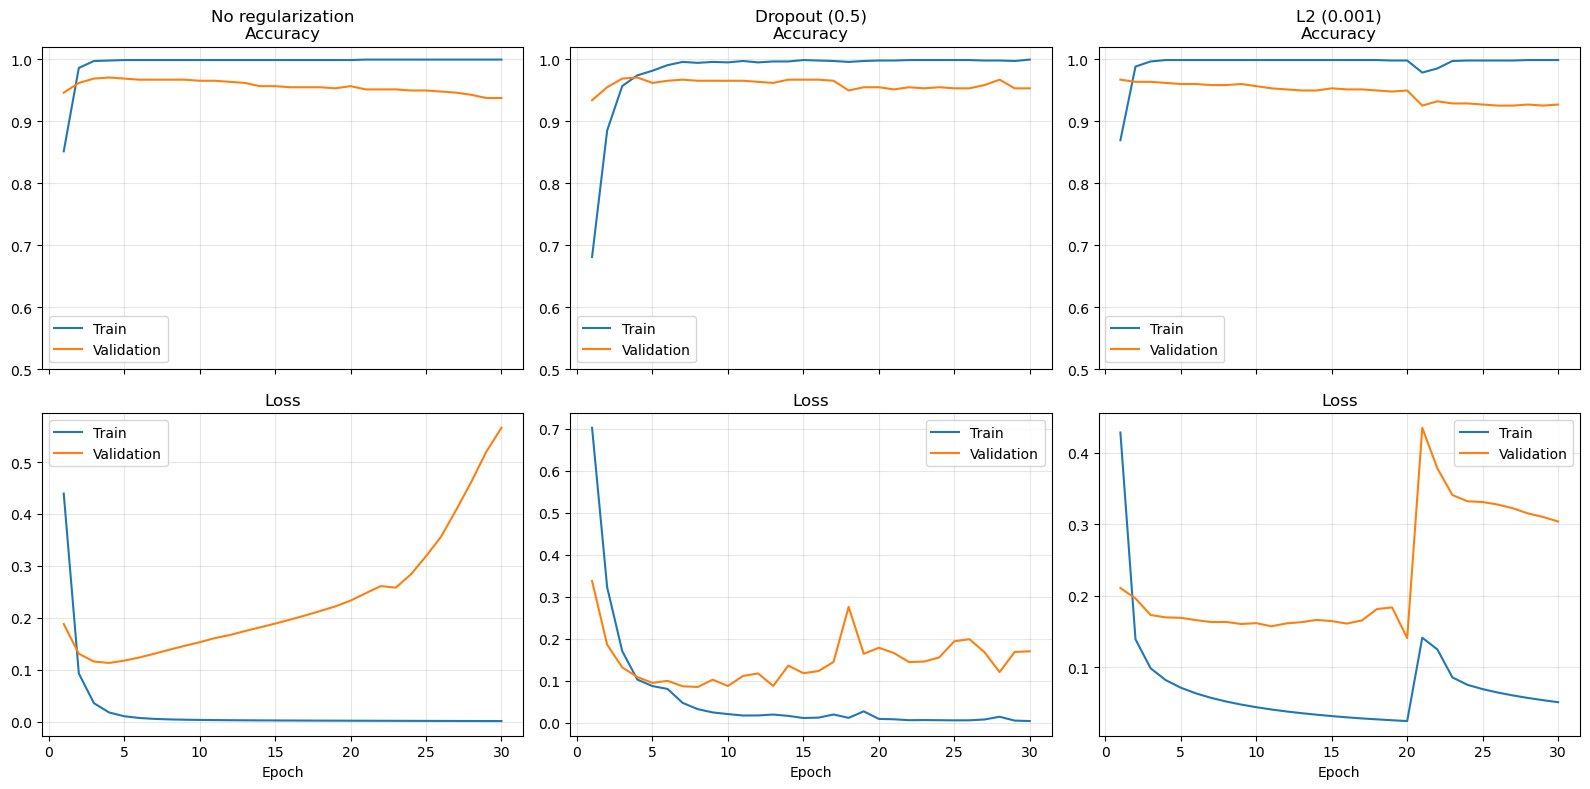

In [7]:
histories = {
    "No regularization": hist_base,
    f"Dropout ({DROPOUT_RATE})": hist_do,
    f"L2 ({L2_LAMBDA})": hist_l2,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)

for col, (name, h) in enumerate(histories.items()):
    hh = h.history
    epochs = range(1, len(hh["loss"]) + 1)

    axes[0, col].plot(epochs, hh["accuracy"], label="Train")
    axes[0, col].plot(epochs, hh["val_accuracy"], label="Validation")
    axes[0, col].set_title(f"{name}\nAccuracy")
    axes[0, col].set_ylim(0.5, 1.02)

    axes[1, col].plot(epochs, hh["loss"], label="Train")
    axes[1, col].plot(epochs, hh["val_loss"], label="Validation")
    axes[1, col].set_title("Loss")
    axes[1, col].set_xlabel("Epoch")

    for row in (0, 1):
        axes[row, col].grid(alpha=0.3)
        axes[row, col].legend()

plt.tight_layout()
plt.show()

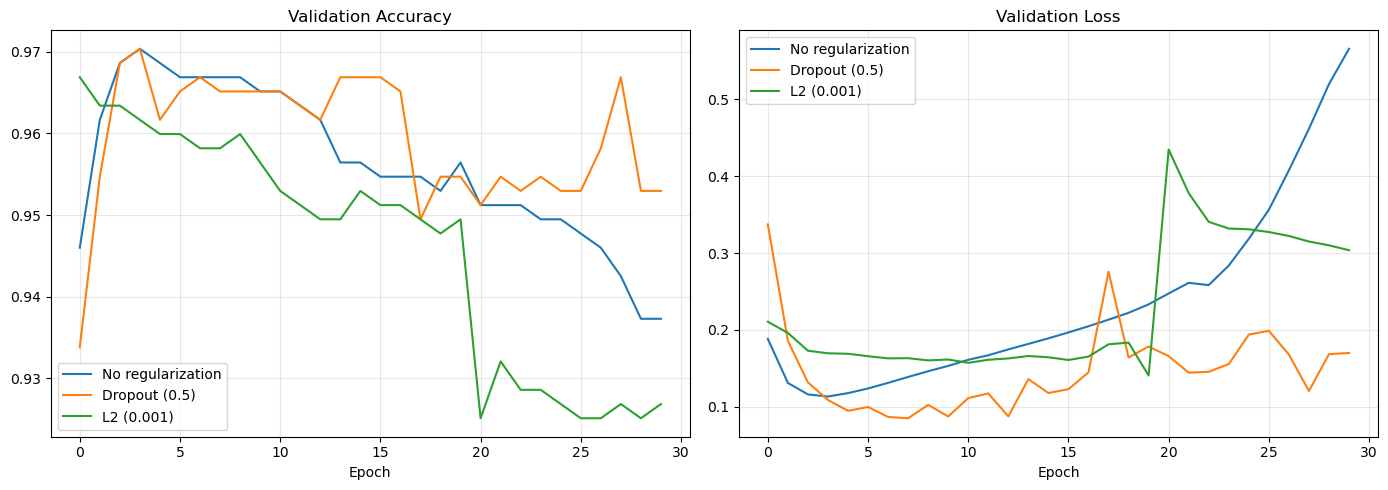

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, h in histories.items():
    axes[0].plot(h.history["val_accuracy"], label=name)
    axes[1].plot(h.history["val_loss"], label=name)

axes[0].set_title("Validation Accuracy"); axes[0].set_xlabel("Epoch")
axes[1].set_title("Validation Loss");     axes[1].set_xlabel("Epoch")
for ax in axes:
    ax.grid(alpha=0.3); ax.legend()

plt.tight_layout()
plt.show()

In [9]:
rows = []
for name, h in histories.items():
    hh = h.history
    best_epoch = int(np.argmin(hh["val_loss"])) + 1
    rows.append({
        "Model": name,
        "Final Train Acc": hh["accuracy"][-1],
        "Final Val Acc": hh["val_accuracy"][-1],
        "Acc Gap (Train-Val)": hh["accuracy"][-1] - hh["val_accuracy"][-1],
        "Final Train Loss": hh["loss"][-1],
        "Final Val Loss": hh["val_loss"][-1],
        "Min Val Loss": min(hh["val_loss"]),
        "Best Epoch (val loss)": best_epoch,
    })

summary = pd.DataFrame(rows).set_index("Model").round(4)
summary

,Final Train Acc,Final Val Acc,Acc Gap (Train-Val),Final Train Loss,Final Val Loss,Min Val Loss,Best Epoch (val loss)
Model,,,,,,,
No regularization,0.9993,0.9373,0.0620,0.0014,0.5659,0.1133,4
Dropout (0.5),0.9993,0.9530,0.0463,0.0038,0.1699,0.0849,8
L2 (0.001),0.9985,0.9268,0.0717,0.0508,0.3037,0.1405,20
